In [1]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")
torch.cuda.set_per_process_memory_fraction(0.5)

Usando dispositivo: cuda


In [2]:
titles_entrenamiento = pd.read_csv('datasets/titles_train.csv', usecols=['id','description', 'imdb_score'])
titles_entrenamiento = titles_entrenamiento[~(titles_entrenamiento['description'].isnull() | titles_entrenamiento['imdb_score'].isnull())]
titles_entrenamiento['id'] = titles_entrenamiento['id'].str.extract(r'(\d+)', expand=False).astype(int)
titles_entrenamiento.set_index('id', inplace=True)
print(titles_entrenamiento.isnull().sum())

titles_entrenamiento

description    0
imdb_score     0
dtype: int64


,description,imdb_score
id,,
127384,"King Arthur, accompanied by his squire, recrui...",8.2
70993,"Brian Cohen is an average young Jewish man, bu...",8.0
190788,12-year-old Regan MacNeil begins to adapt an e...,8.1
14873,When a madman dubbed 'Scorpio' terrorizes San ...,7.7
98978,Two small children and a ship's cook survive a...,5.8
...,...,...
1004011,When a ballroom dancer’s shot at a crucial tou...,2.2
1040816,Three women with totally different lives accid...,5.8
1014599,A beautiful love story that can happen between...,6.9


Asumo que `description` esta completamente en ingles.

### Setup

In [3]:
# Using English BERT model
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)

texto = titles_entrenamiento['description'].iloc[0]
tokens = tokenizer.tokenize(texto)
print(texto)
print(tokens)

King Arthur, accompanied by his squire, recruits his Knights of the Round Table, including Sir Bedevere the Wise, Sir Lancelot the Brave, Sir Robin the Not-Quite-So-Brave-As-Sir-Lancelot and Sir Galahad the Pure. On the way, Arthur battles the Black Knight who, despite having had all his limbs chopped off, insists he can still fight. They reach Camelot, but Arthur decides not  to enter, as "it is a silly place".
['king', 'arthur', ',', 'accompanied', 'by', 'his', 'squire', ',', 'recruits', 'his', 'knights', 'of', 'the', 'round', 'table', ',', 'including', 'sir', 'bed', '##ever', '##e', 'the', 'wise', ',', 'sir', 'lance', '##lot', 'the', 'brave', ',', 'sir', 'robin', 'the', 'not', '-', 'quite', '-', 'so', '-', 'brave', '-', 'as', '-', 'sir', '-', 'lance', '##lot', 'and', 'sir', 'gala', '##had', 'the', 'pure', '.', 'on', 'the', 'way', ',', 'arthur', 'battles', 'the', 'black', 'knight', 'who', ',', 'despite', 'having', 'had', 'all', 'his', 'limbs', 'chopped', 'off', ',', 'insists', 'he', 

In [4]:
ids = tokenizer.convert_tokens_to_ids(tokens)
print(ids)

[2332, 4300, 1010, 5642, 2011, 2010, 21263, 1010, 15024, 2010, 7307, 1997, 1996, 2461, 2795, 1010, 2164, 2909, 2793, 22507, 2063, 1996, 7968, 1010, 2909, 9993, 10994, 1996, 9191, 1010, 2909, 5863, 1996, 2025, 1011, 3243, 1011, 2061, 1011, 9191, 1011, 2004, 1011, 2909, 1011, 9993, 10994, 1998, 2909, 16122, 16102, 1996, 5760, 1012, 2006, 1996, 2126, 1010, 4300, 7465, 1996, 2304, 5000, 2040, 1010, 2750, 2383, 2018, 2035, 2010, 10726, 24881, 2125, 1010, 16818, 2002, 2064, 2145, 2954, 1012, 2027, 3362, 19130, 4140, 1010, 2021, 4300, 7288, 2025, 2000, 4607, 1010, 2004, 1000, 2009, 2003, 1037, 10021, 2173, 1000, 1012]


In [5]:
titles_entrenamiento['description'] = titles_entrenamiento['description'].astype(str).apply(lambda txt: tokenizer.tokenize(txt))
titles_entrenamiento

,description,imdb_score
id,,
127384,"[king, arthur, ,, accompanied, by, his, squire...",8.2
70993,"[brian, cohen, is, an, average, young, jewish,...",8.0
190788,"[12, -, year, -, old, regan, mac, ##neil, begi...",8.1
14873,"[when, a, madman, dubbed, ', sc, ##or, ##pio, ...",7.7
98978,"[two, small, children, and, a, ship, ', s, coo...",5.8
...,...,...
1004011,"[when, a, ballroom, dancer, ’, s, shot, at, a,...",2.2
1040816,"[three, women, with, totally, different, lives...",5.8
1014599,"[a, beautiful, love, story, that, can, happen,...",6.9


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(titles_entrenamiento['description'], titles_entrenamiento['imdb_score'],
                                                  test_size=0.2, random_state=28)

In [7]:
# Load the BERT model
bertmodel = BertModel.from_pretrained(model_name).to(device).eval()

def get_english_token_embedding(token: str):
    """
    Returns the static embedding for the token using English BERT.
    """
    token_id = tokenizer.convert_tokens_to_ids(token)
    if token_id is None or token_id == tokenizer.unk_token_id:
        print(f"❌ The token '{token}' is not in the English BERT vocabulary.")
        return None
    embedding_vector = bertmodel.embeddings.word_embeddings.weight[token_id]
    return embedding_vector

In [8]:
from torch.utils.data import Dataset

class dataset_token(Dataset):
    def __init__(self, X_tokens, y):
        self.pairs = list(zip(X_tokens, y))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        token, ys = self.pairs[idx]
        hidden = get_english_token_embedding(token).to(device)
        return {
            'input': hidden,
            'target': torch.tensor(ys).to(device),
            'input_length': torch.tensor(hidden.shape).to(device),
            'target_length': torch.tensor(1).to(device)
    }

train_dataset = dataset_token(X_train, y_train)
val_dataset = dataset_token(X_val, y_val)

print('Primer elemento del dataset de entrenamiento:', train_dataset[1])

Primer elemento del dataset de entrenamiento: {'input': tensor([[-0.0185, -0.0066,  0.0006,  ..., -0.0854, -0.0240, -0.0585],
        [ 0.0149, -0.0022, -0.0540,  ...,  0.0320,  0.0138, -0.0123],
        [-0.0558, -0.0204, -0.0345,  ..., -0.0074, -0.0254, -0.0253],
        ...,
        [ 0.0017, -0.0560, -0.0377,  ..., -0.0032,  0.0071, -0.0190],
        [ 0.0514, -0.0479, -0.0784,  ..., -0.0627,  0.0314, -0.0292],
        [-0.0207, -0.0020, -0.0118,  ...,  0.0128,  0.0200,  0.0259]],
       device='cuda:0', grad_fn=<IndexBackward0>), 'target': tensor(5.5000, device='cuda:0'), 'input_length': tensor([ 62, 768], device='cuda:0'), 'target_length': tensor(1, device='cuda:0')}


In [9]:
import time

def train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS):
    train_losses = []
    val_losses = []

    print("Iniciando entrenamiento...")
    print("-" * 50)
    start_time = time.time()
    for epoch in range(NUM_EPOCHS):
        # Entrenamiento
        model.train()
        train_loss = 0
        n = 0

        for batch_idx, batch in enumerate(train_dataloader):
            input = batch['input']
            target = batch['target'].unsqueeze(1).to(device)

            optimizer.zero_grad()

            output = model.forward(input)
            loss = criterion(output, target)

            loss.backward()

            # Gradient clipping para evitar exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()
            n += 1

        train_loss /= n
        train_losses.append(train_loss)

        # Validación
        model.eval()
        val_loss = 0
        m = 0
        with torch.no_grad():
            for batch_idx, batch in enumerate(val_dataloader):
                input = batch['input']
                target = batch['target'].unsqueeze(1).to(device)

                output = model.forward(input)
                loss = criterion(output, target)
                val_loss += loss.item()
                m += 1
        val_loss /= m
        val_losses.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f'Época {epoch+1}/{NUM_EPOCHS}')
            print(f'  Pérdida Entrenamiento: {train_loss:.4f}')
            print(f'  Pérdida Testeo: {val_loss:.4f}')
            print(f'  {"Mejorando" if val_loss < min(val_losses[:-1] + [float("inf")]) else "Empeorando"}')
    
    end_time = time.time()
    print(f"Entrenamiento completado! Tiempo total: {end_time - start_time:.2f} segundos")
    return train_losses, val_losses

### Model 1

In [10]:
class gruregressor(nn.Module):
    def __init__(self, seq_len, hidden_size):
        super().__init__()
        self.GRU1 = nn.GRU(input_size=seq_len, hidden_size=hidden_size, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(2*hidden_size, 1)
        self.Linear = nn.Linear(in_features=2*hidden_size, out_features=1)

    def forward(self, input_seq):
        # input_seq: (batch, time, features)
        out, _ = self.GRU1(input_seq)
        # attention
        attn_weights = torch.softmax(self.attn(out).squeeze(-1), dim=1)  # (batch, time)
        context = torch.sum(out * attn_weights.unsqueeze(-1), dim=1)     # (batch, 2*hidden_size)
        outputs = self.Linear(context)
        return outputs

In [14]:
from torch.nn.utils.rnn import pad_sequence

def custom_collate(batch):
    inputs = [item['input'] for item in batch]
    targets = torch.tensor([item['target'] for item in batch])
    lengths = torch.tensor([inp.shape[0] for inp in inputs])
    padded_inputs = pad_sequence(inputs, batch_first=True)  # [batch, max_len, 768]
    return {'input': padded_inputs, 'target': targets, 'input_length': lengths}

from torch.utils.data import DataLoader
BATCH_SIZE = 100

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate)

In [15]:
LEARNING_RATE = 0.0001
NUM_EPOCHS = 50
HIDDEN_SIZE = 32

# Inicializa el modelo 
model = gruregressor(seq_len=768, hidden_size=HIDDEN_SIZE).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 154114 parámetros


In [16]:
#### Entrenamiento del modelo #####
train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)

Iniciando entrenamiento...
--------------------------------------------------
Época 5/50
  Pérdida Entrenamiento: 36.9619
  Pérdida Testeo: 35.4118
  Mejorando
Época 10/50
  Pérdida Entrenamiento: 14.7032
  Pérdida Testeo: 12.9983
  Mejorando
Época 15/50
  Pérdida Entrenamiento: 4.0950
  Pérdida Testeo: 3.6112
  Mejorando
Época 20/50
  Pérdida Entrenamiento: 1.3657
  Pérdida Testeo: 1.3559
  Mejorando
Época 25/50
  Pérdida Entrenamiento: 1.3163
  Pérdida Testeo: 1.3483
  Mejorando
Época 30/50
  Pérdida Entrenamiento: 1.3118
  Pérdida Testeo: 1.3464
  Mejorando
Época 35/50
  Pérdida Entrenamiento: 1.3088
  Pérdida Testeo: 1.3452
  Mejorando
Época 40/50
  Pérdida Entrenamiento: 1.3064
  Pérdida Testeo: 1.3440
  Mejorando
Época 45/50
  Pérdida Entrenamiento: 1.3042
  Pérdida Testeo: 1.3428
  Mejorando
Época 50/50
  Pérdida Entrenamiento: 1.3020
  Pérdida Testeo: 1.3414
  Mejorando
Entrenamiento completado! Tiempo total: 330.57 segundos


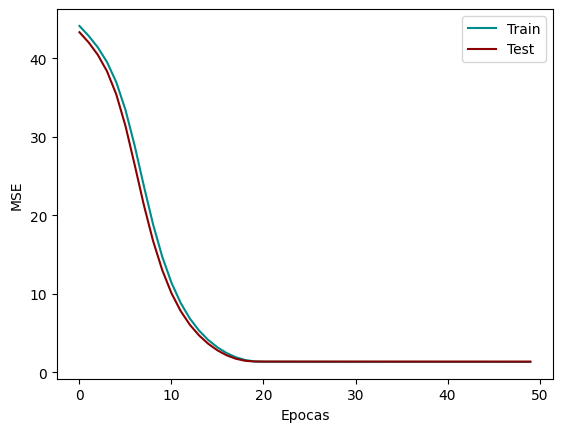

In [17]:
plt.plot(train_losses, label='Train', c='darkcyan')
plt.plot(val_losses, label='Test', c='darkred')
plt.xlabel('Epocas')
plt.ylabel('MSE')
plt.legend()